In [401]:
import os
import re
import time
import random
import warnings
from IPython.display import IFrame  # Для отображения файлов в Jupyter

# Импорт библиотек для работы с БД
import psycopg2
from sqlalchemy import create_engine, inspect
import sqlite3
# Импорт библиотек для научных вычислений и визуализации данных
import numpy as np
import pandas as pd
import seaborn as sns
!pip -q install shap
import plotly.express as px
import matplotlib.pyplot as plt
!pip install tabulate
from tabulate import tabulate
!pip install phik
from phik.report import plot_correlation_matrix
from phik import phik_matrix
# Импорт библиотек для анализа корреляций и отчетов



# Расчет статистик
from sklearn.metrics import (
    accuracy_score, 
    classification_report,
    f1_score, 
    precision_score,
    recall_score, 
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix, 
    ConfusionMatrixDisplay
)

# Импорт библиотек для предобработки данных и работы с моделями
!pip install --upgrade scikit-learn
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.experimental import enable_halving_search_cv  # Необходимо для HalvingSearch
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    HalvingRandomSearchCV,  # После импорта enable_halving_search_cv это будет работать
    HalvingGridSearchCV,    # Также заработает после импорта enable_halving_search_cv
    RandomizedSearchCV, 
    GridSearchCV,
    KFold,
    train_test_split
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier, Pool, cv 
from sklearn.preprocessing import (
    LabelEncoder,
    OrdinalEncoder,
    OneHotEncoder,
    StandardScaler, 
    MinMaxScaler
)

import lightgbm as lgb
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier

# Модели машинного обучения
from sklearn.dummy import DummyClassifier

# Импорт библиотек для работы с PyTorch
import torch  # Основная библиотека для работы с тензорами
import torch.nn as nn  # Модуль для создания нейронных сетей
import torch.optim as optim  # Модуль для оптимизации
# Для работы с загрузкой данных
from torch.utils.data import DataLoader, TensorDataset
!pip install shap
import shap

# Настройка отображения в Pandas, чтобы видеть весь список параметров
pd.set_option('display.max_colwidth', None)
pd.options.display.max_columns = None # Установка опции для отображения всех столбцов

# Отключаем предупреждение
warnings.filterwarnings("ignore", category=FutureWarning)

# Константы
LINE_1 = '-' * 125
RANDOM_STATE = 210424
TEST_SIZE = 0.25
N_FOLDS = 5

# Введение

В нашем распоряжении данные оператора связи «ТелеДом», который хочет бороться с оттоком клиентов. Наша цель проанализировать эти данные и при помощи моделей машинного обучения и решить задачу:

Нужно создать модель, которая которая сможет предсказать отток клиентов, чтобы предлагать промокоды и специальные условия всем, кто планирует отказаться от услуг связи.

План нашего проекта такой:

1) Подключимся к базе и загрузим таблицы sql

2) Исследуем наши таблицы

3) Объединим таблицы и предобработаем данных

4) Проведем корреляционный анализ

5) Подготовим данные для обучения

6) Обучим модели и проведем анализ полученных результатов

7) Проведем анализ важности факторов

## Подключение к базе и  Загрузка таблиц sql

In [190]:
!wget https://code.s3.yandex.net/data-scientist/ds-plus-final.db

--2025-04-29 20:44:19--  https://code.s3.yandex.net/data-scientist/ds-plus-final.db
Resolving code.s3.yandex.net (code.s3.yandex.net)... 93.158.134.158, 2a02:6b8::2:158
Connecting to code.s3.yandex.net (code.s3.yandex.net)|93.158.134.158|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3588096 (3.4M) [application/octet-stream]
Saving to: ‘ds-plus-final.db.7’

ds-plus-final.db.7  100%[===================>]   3.42M  --.-KB/s    in 0.06s   

2025-04-29 20:44:20 (58.1 MB/s) - ‘ds-plus-final.db.7’ saved [3588096/3588096]



In [196]:
path_to_db = 'ds-plus-final.db.1'

In [197]:

engine = create_engine(f'sqlite:///{path_to_db}', echo=False) 

In [198]:

connection = sqlite3.connect(path_to_db)

Создадим функцию для выполнения SQL запроса и прочтения результатов:

In [199]:

def execute_query(query):
    return pd.read_sql(query, engine)

Выведем по 5 строк из каждой таблицы

In [200]:

table_names = ['contract', 'personal', 'internet', 'phone']

for tabel in table_names:
    display(execute_query(f"""SELECT * 
        FROM {tabel} 
        LIMIT 5"""))

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84
2,3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.85,226.17
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.3,1960.6
4,9237-HQITU,2019-09-01,No,Month-to-month,Yes,Electronic check,70.7,353.5


,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


,CustomerId,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


Итак, на этапе подключение к базе и Загрузка таблиц sql мы подключились к БД и провели первичный осмотр таблиц.

## Первичное исследование таблиц

На этапе загрузки данных мы убедились, что количество табилц соотвествует условию, а общий ключ имеется у всех таблиц.

Исследуем наши данные на пропуски и исследуем информацию о столбцах. Создадим для этого функции:

In [201]:
def execute_query(query, connection=connection): # connection по умолчанию
    try:
        result = pd.read_sql_query(query, connection)
    except Exception as e:
        print(f"Ошибка при выполнении запроса: {e}")
        result = None
    return result

In [202]:
def check_nulls(table_name, connection=connection): # connection по умолчанию
    cursor = connection.cursor()
    cursor.execute(f"PRAGMA table_info({table_name});")
    columns = [row[1] for row in cursor.fetchall()]
    results = []

    for col in columns:
        query = f"""
        SELECT 
            '{col}' AS column_name,
            COUNT(*) AS total_rows,
            COUNT({col}) AS non_null_rows,
            COUNT(*) - COUNT({col}) AS null_values,
            (COUNT(*) - COUNT({col})) * 100.0 / COUNT(*) AS null_percentage
        FROM {table_name};
        """
        result = execute_query(query, connection) # Передаем коннект
        results.append(result)

    return pd.concat(results, ignore_index=True)

In [203]:
def display_table_info(table_names, connection=connection): # connection по умолчанию
    for table in table_names:
        print(f"\nИнформация и пропуски для таблицы {table}:")

        # Получение информации о столбцах с помощью PRAGMA
        cursor = connection.cursor()
        cursor.execute(f"PRAGMA table_info({table});")
        columns_info = cursor.fetchall()
        columns_info_df = pd.DataFrame(columns_info, columns=["cid", "name", "type", "notnull", "dflt_value", "pk"])

        # Переименование столбца 'name' в 'column_name'
        columns_info_df = columns_info_df.rename(columns={'name': 'column_name'})

        # Выбор только необходимых столбцов
        columns_info_df = columns_info_df[['column_name', 'type', 'notnull']]

        # Замена числовых значений в столбце 'notnull' на 'YES' и 'NO'
        columns_info_df['notnull'] = columns_info_df['notnull'].replace({0: 'NO', 1: 'YES'})

        # Переименование столбца
        columns_info_df = columns_info_df.rename(columns={'type': 'data_type', 'notnull': 'is_nullable'})


        nulls_info = check_nulls(table, connection) # Передаем коннект


        combined_info = pd.merge(columns_info_df, nulls_info, on='column_name', how='left')
        display(combined_info)
        print(LINE_1)

Применим нашу итоговую функцию:

In [204]:
display_table_info(table_names)


Информация и пропуски для таблицы contract:


,column_name,data_type,is_nullable,total_rows,non_null_rows,null_values,null_percentage
0,customerID,text,NO,7043,7043,0,0.0
1,BeginDate,text,NO,7043,7043,0,0.0
2,EndDate,text,NO,7043,7043,0,0.0
3,Type,text,NO,7043,7043,0,0.0
4,PaperlessBilling,text,NO,7043,7043,0,0.0
5,PaymentMethod,text,NO,7043,7043,0,0.0
6,MonthlyCharges,text,NO,7043,7043,0,0.0
7,TotalCharges,text,NO,7043,7043,0,0.0


-----------------------------------------------------------------------------------------------------------------------------

Информация и пропуски для таблицы personal:


,column_name,data_type,is_nullable,total_rows,non_null_rows,null_values,null_percentage
0,customerID,text,NO,7043,7043,0,0.0
1,gender,text,NO,7043,7043,0,0.0
2,SeniorCitizen,text,NO,7043,7043,0,0.0
3,Partner,text,NO,7043,7043,0,0.0
4,Dependents,text,NO,7043,7043,0,0.0


-----------------------------------------------------------------------------------------------------------------------------

Информация и пропуски для таблицы internet:


,column_name,data_type,is_nullable,total_rows,non_null_rows,null_values,null_percentage
0,customerID,text,NO,5517,5517,0,0.0
1,InternetService,text,NO,5517,5517,0,0.0
2,OnlineSecurity,text,NO,5517,5517,0,0.0
3,OnlineBackup,text,NO,5517,5517,0,0.0
4,DeviceProtection,text,NO,5517,5517,0,0.0
5,TechSupport,text,NO,5517,5517,0,0.0
6,StreamingTV,text,NO,5517,5517,0,0.0
7,StreamingMovies,text,NO,5517,5517,0,0.0


-----------------------------------------------------------------------------------------------------------------------------

Информация и пропуски для таблицы phone:


,column_name,data_type,is_nullable,total_rows,non_null_rows,null_values,null_percentage
0,CustomerId,text,NO,6361,6361,0,0.0
1,MultipleLines,text,NO,6361,6361,0,0.0


-----------------------------------------------------------------------------------------------------------------------------


Анализ данных выявил следующее:

- В таблице `contract` (7043 записей) не содержит пропущенных значений в ключевых столбцах. 
- В таблице `personal` (7043 записей) не содержит пропущенных значений в ключевых столбцах.
- В таблице `internet` (5517 записей) не содержит пропущенных значений в ключевых столбцах.
- В таблице `phone` (6361 записей) не содержит пропущенных значений в ключевых столбцах.

Проведем статистический анализ всех наших данных. Напишем функцию для агрегирования и обработки наших данных:

In [205]:
def get_typeof_condition(data_types):
    if any(dtype in ['integer', 'real', 'float', 'numeric'] for dtype in data_types):
        return "IN ('integer', 'real')" # SQLite typeof returns 'integer' or 'real' for numeric types
    elif any(dtype in ['text', 'varchar', 'char'] for dtype in data_types):
        return "= 'text'"
    else:
        return ""

In [206]:
def get_columns(table_name, data_types):
    try:
        inspector = inspect(engine) # Получаем inspector один раз

        sql = f"""
            SELECT name
            FROM pragma_table_info('{table_name}')
            WHERE typeof(name) {get_typeof_condition(data_types)}
        """
        cols = pd.read_sql_query(sql, engine)['name'].tolist()

        return cols

    except Exception as e:
        print(f"Ошибка при получении столбцов таблицы {table_name}: {e}")
        return []

In [207]:
def execute_query(query):
    try:
        return pd.read_sql_query(query, engine)
    except Exception as e:
        print(f"Ошибка SQL запроса: {e}")
        return None

def get_columns(table_name, data_types):
    try:
        query = f"SELECT name FROM pragma_table_info('{table_name}');"
        columns_df = execute_query(query)

        if columns_df is not None:
            # SQLite не всегда точно определяет типы данных. Проверяем вручную.
            columns = []
            for col in columns_df['name'].tolist():
                try:
                    typeof_query = f"SELECT typeof({col}) FROM {table_name} LIMIT 1"
                    data_type = engine.execute(typeof_query).scalar()
                    if data_type and data_type.lower() in data_types:
                        columns.append(col)
                except Exception as e:
                    print(f"Ошибка определения типа данных для столбца {col}: {e}")

            return columns
        else:
            return []

    except Exception as e:
        print(f"Ошибка при получении столбцов таблицы {table_name}: {e}")
        return []

In [208]:

def get_aggregate_stats(table_name, drop_columns=None):
    # Получаем числовые столбцы
    numeric_columns = get_columns(table_name, data_types=['integer', 'real', 'float', 'numeric'])
    # Получаем категориальные столбцы
    categorical_columns = get_columns(table_name, data_types=['text', 'varchar', 'char'])

    # Если указаны столбцы для удаления, удаляем их из списка
    if drop_columns:
        numeric_columns = [col for col in numeric_columns if col not in drop_columns]
        categorical_columns = [col for col in categorical_columns if col not in drop_columns]

    numeric_stats = None
    categorical_stats = None

    # Статистика для числовых столбцов
    if numeric_columns:
        query_parts = []

        # Агрегации для числовых столбцов
        for col in numeric_columns:
            query_parts.append(f"COUNT({col}) AS count_{col}")
            query_parts.append(f"AVG({col}) AS mean_{col}")
            query_parts.append(f"STDDEV({col}) AS stddev_{col}")
            query_parts.append(f"MIN({col}) AS min_{col}")
            query_parts.append(f"PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY {col}) AS p25_{col}")
            query_parts.append(f"PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY {col}) AS median_{col}")
            query_parts.append(f"PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY {col}) AS p75_{col}")
            query_parts.append(f"MAX({col}) AS max_{col}")

        query = f"SELECT {', '.join(query_parts)} FROM {table_name}"
        
        try:
            result = execute_query(query)
            # Округление значений до 2 знаков
            result = result.round(2)
            
            result_transposed = result.transpose()
            result_transposed.columns = ['value']
            result_transposed.reset_index(inplace=True)
            result_transposed[['metric', 'column']] = result_transposed['index'].apply(
                lambda x: pd.Series(x.split('_', 1) if '_' in x else [x, None])
            )

            # Переименование метрик для соответствия describe()
            rename_dict = {
                'count': 'count',
                'mean': 'mean',
                'stddev': 'std',
                'min': 'min',
                'p25': '25%',
                'median': '50%',
                'p75': '75%',
                'max': 'max'
            }
            result_transposed['metric'] = result_transposed['metric'].replace(rename_dict)

            # Установка порядка метрик
            ordered_metrics = ['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']
            result_transposed['metric'] = pd.Categorical(result_transposed['metric'], categories=ordered_metrics, ordered=True)
            result_transposed.sort_values(by='metric', inplace=True)

            numeric_stats = result_transposed.pivot(index='metric', columns='column', values='value')
            numeric_stats.index.name = None
            numeric_stats.columns.name = None
        except Exception as e:
            print(f"Ошибка при обработке числовых данных таблицы {table_name}: {str(e)}")

    # Статистика для категориальных столбцов
    if categorical_columns:
        query_parts = []


        for col in categorical_columns:
            query_parts.append(f"COUNT({col}) AS count_{col}")
            query_parts.append(f"COUNT(DISTINCT {col}) AS unique_{col}")

            # Замена MODE() на подзапрос с COUNT и GROUP BY
            mode_subquery = f"""
                SELECT {col}
                FROM {table_name}
                GROUP BY {col}
                ORDER BY COUNT(*) DESC
                LIMIT 1
            """
            query_parts.append(f"({mode_subquery}) AS mode_{col}")

            freq_subquery = f"""
                SELECT COUNT(*)
                FROM {table_name}
                WHERE {col} = ({mode_subquery})
            """
            query_parts.append(f"({freq_subquery}) AS freq_{col}")


        query = f"SELECT {', '.join(query_parts)} FROM {table_name}"

        try:
            result = execute_query(query)
            if result is not None and not result.empty:
                result_transposed = result.transpose()
                result_transposed.columns = ['value']
                result_transposed.reset_index(inplace=True)
                result_transposed[['metric', 'column']] = result_transposed['index'].apply(
                    lambda x: pd.Series(x.split('_', 1) if '_' in x else [x, None])
                )
            elif result is None:
                print(f"Ошибка SQL запроса для таблицы {table_name}: execute_query вернул None.")
            else:
                print(f"Таблица {table_name} не содержит данных для категориальных столбцов.")


            # Установка порядка метрик для категориальных данных
            ordered_metrics = ['count', 'unique', 'mode', 'freq']
            result_transposed['metric'] = pd.Categorical(result_transposed['metric'], categories=ordered_metrics, ordered=True)
            result_transposed.sort_values(by='metric', inplace=True)

            categorical_stats = result_transposed.pivot(index='metric', columns='column', values='value')
            categorical_stats.index.name = None
            categorical_stats.columns.name = None
        except Exception as e:
            print(f"Ошибка при обработке категориальных данных таблицы {table_name}: {str(e)}")

    return numeric_stats, categorical_stats                                                                                                                                                                                                                                                                                                                                                     

In [209]:
drop_columns = ['customerID'] 
for table_name in table_names:
    print(f"\nСтатистика по данным {table_name}:")
    numeric_stats, categorical_stats = get_aggregate_stats(table_name, drop_columns=drop_columns)

    if numeric_stats is not None:
        print("\nЧисловые данные:")
        display(numeric_stats)
    if categorical_stats is not None:
        print("\nКатегориальные данные:")
        display(categorical_stats)
    print(LINE_1)


Статистика по данным contract:

Категориальные данные:


,BeginDate,EndDate,MonthlyCharges,PaperlessBilling,PaymentMethod,TotalCharges,Type
count,7043,7043,7043,7043,7043,7043,7043
unique,77,67,1585,2,4,6658,3
mode,2014-02-01,No,20.05,Yes,Electronic check,,Month-to-month
freq,366,5942,61,4171,2365,11,3875


-----------------------------------------------------------------------------------------------------------------------------

Статистика по данным personal:

Категориальные данные:


,Dependents,Partner,SeniorCitizen,gender
count,7043,7043,7043,7043
unique,2,2,2,2
mode,No,No,0,Male
freq,4933,3641,5901,3555


-----------------------------------------------------------------------------------------------------------------------------

Статистика по данным internet:

Категориальные данные:


,DeviceProtection,InternetService,OnlineBackup,OnlineSecurity,StreamingMovies,StreamingTV,TechSupport
count,5517,5517,5517,5517,5517,5517,5517
unique,2,2,2,2,2,2,2
mode,No,Fiber optic,No,No,No,No,No
freq,3095,3096,3088,3498,2785,2810,3473


-----------------------------------------------------------------------------------------------------------------------------

Статистика по данным phone:

Категориальные данные:


,CustomerId,MultipleLines
count,6361,6361
unique,6361,2
mode,9993-LHIEB,No
freq,1,3390


-----------------------------------------------------------------------------------------------------------------------------


Больше всего данных в таблице с информацией о договорах представлено за 1 фераля 2014. Тип платежа чаще всег электронный, а тип оплаты ежемесячный.

В таблице с информацией о персональных данных клиентов данные представлены равномерно (50% мужчин и 50% женщин). Чаще всего клиенты не имеют детей и не имеют партнера. Также в большинстве сулчаев клиент не является пенсионером.

В таблице с информацией об интернете  клиент чаще всего подключен по оптоволокну и не имеет остальных услуг.

Таблице с информацей об услугах телефонии чаще всего клиенты не подключают телефон к нескольким линиям одновременно.

Построим countplot для категориальных данных с использованием батчей. Создадим для этого функцию:

In [210]:
def plot_countplot_in_batches(table_name, batch_size=5, drop_columns=drop_columns):
    categorical_columns = get_columns(table_name, data_types=['text', 'varchar', 'char'])
    if drop_columns:
        categorical_columns = [col for col in categorical_columns if col not in drop_columns]
    for i in range(0, len(categorical_columns), batch_size):
        batch_columns = categorical_columns[i:i+batch_size]
        
        for col in batch_columns:
            query = f"SELECT {col} FROM {table_name} WHERE {col} IS NOT NULL;"
            df = execute_query(query)
            top_20 = df[col].value_counts().nlargest(20)
            plt.figure(figsize=(15, 5))
            sns.countplot(y=df[col], palette="Set2", order=top_20.index)
            plt.title(f"Топ-20 значений для {col}", fontsize=16, fontweight='bold')
            plt.xlabel('Количество', fontsize=14)
            plt.ylabel(col, fontsize=14)
            plt.xticks(fontsize=12)
            plt.yticks(fontsize=12)
            plt.grid(True, linestyle='--', alpha=0.6)
            plt.show()

Сountplot для таблицы: contract


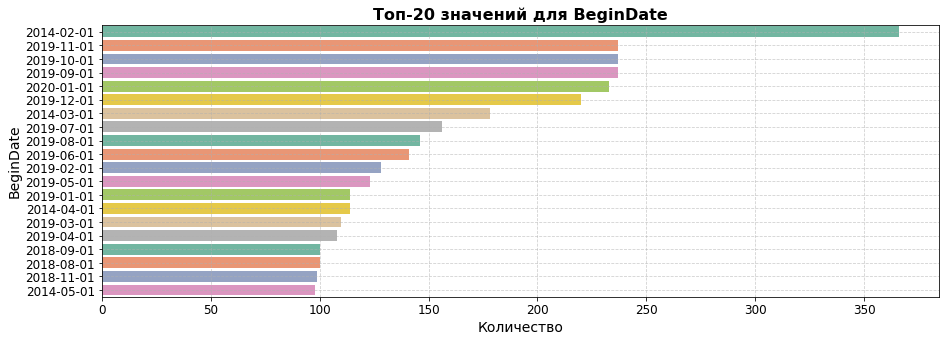

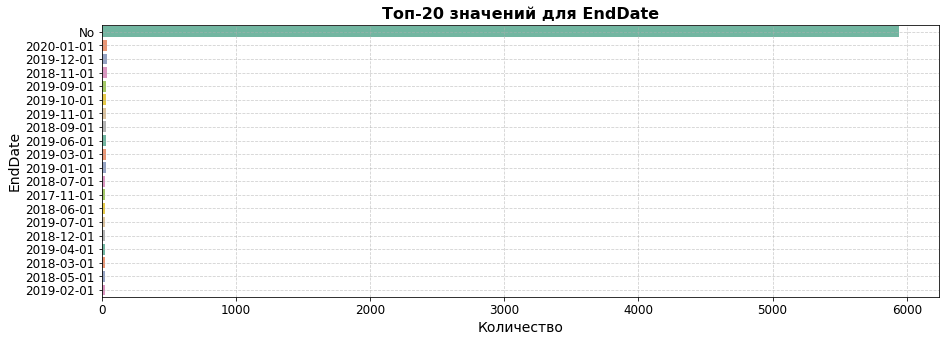

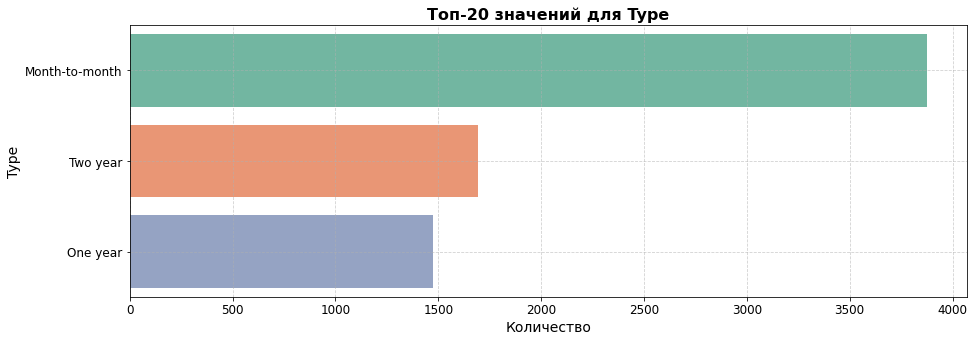

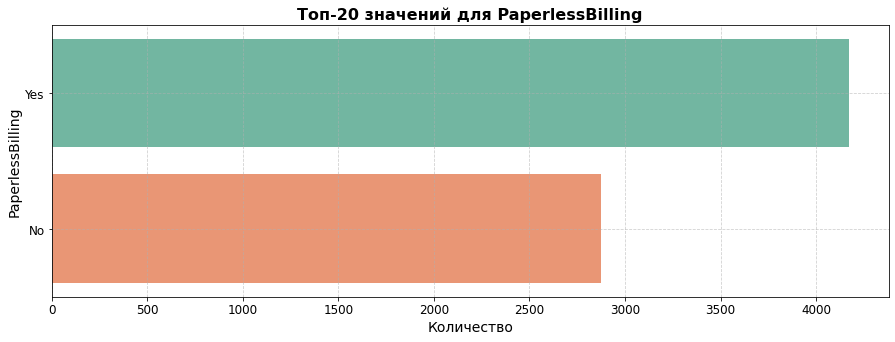

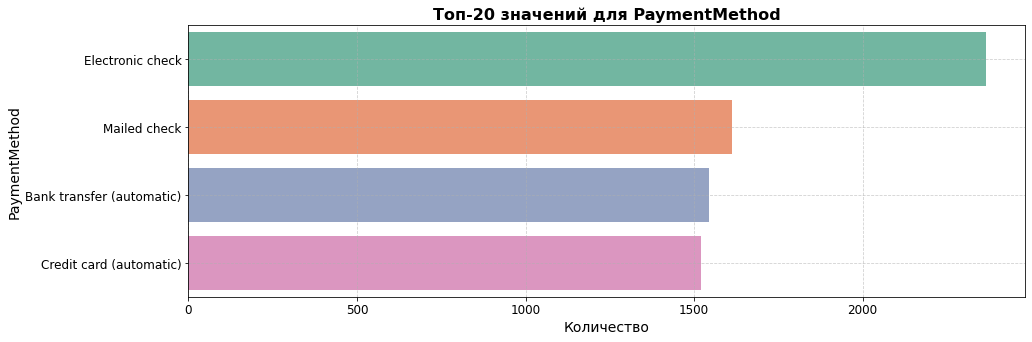

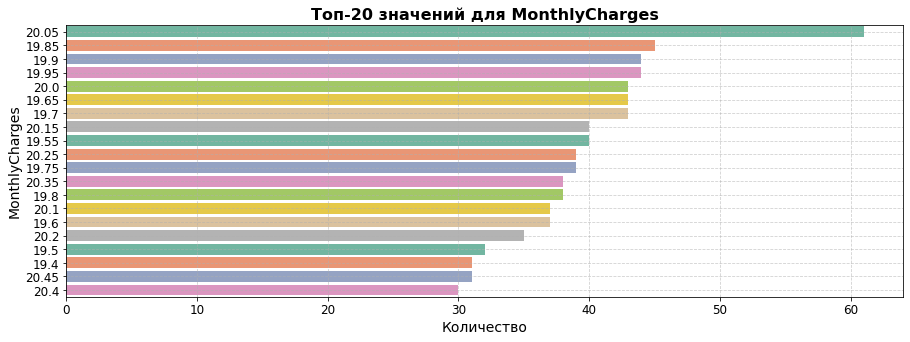

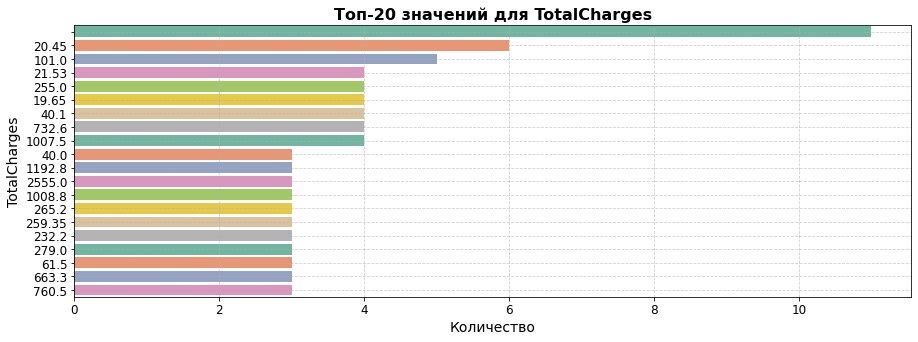

Сountplot для таблицы: personal


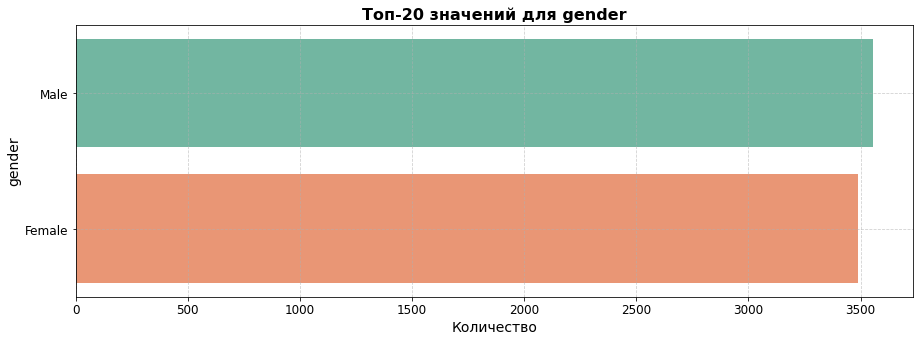

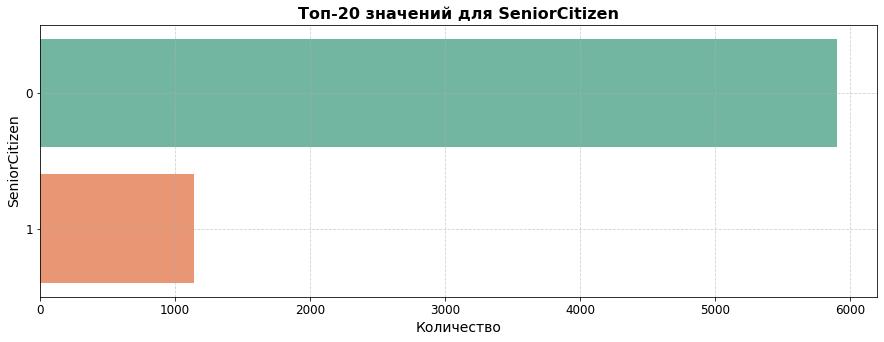

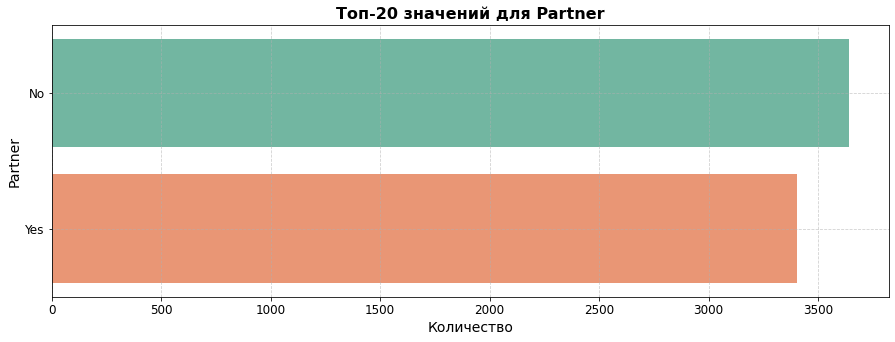

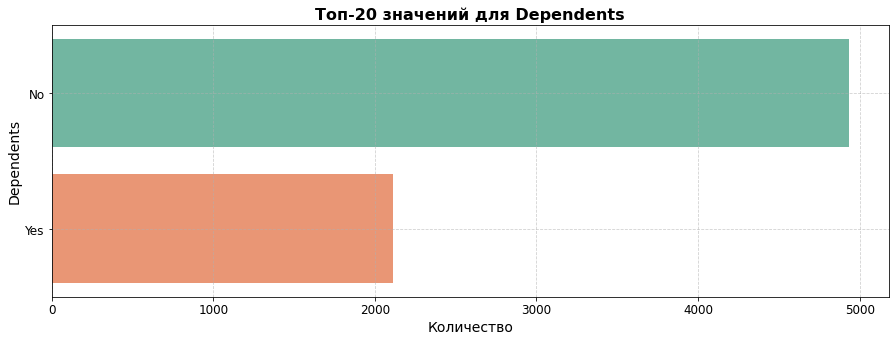

Сountplot для таблицы: internet


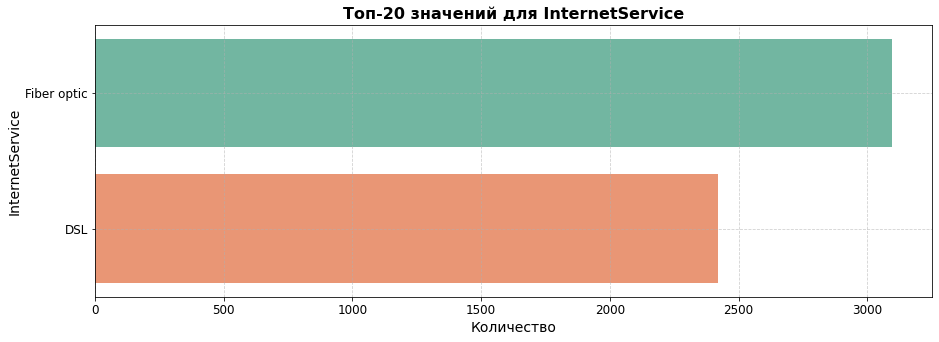

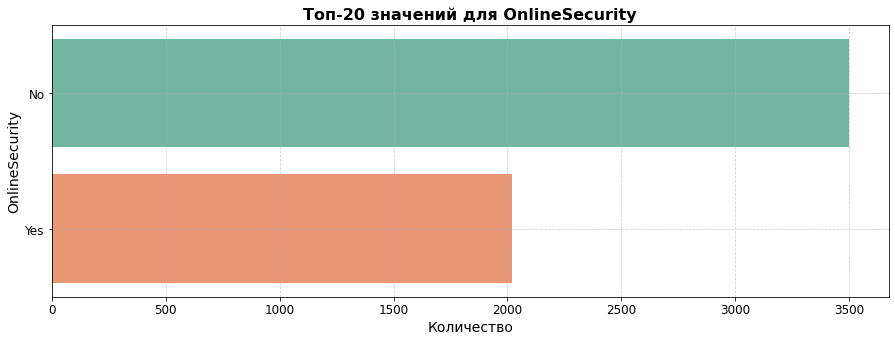

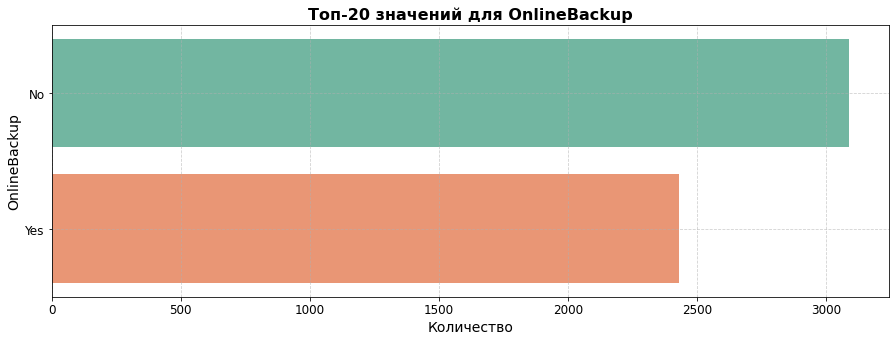

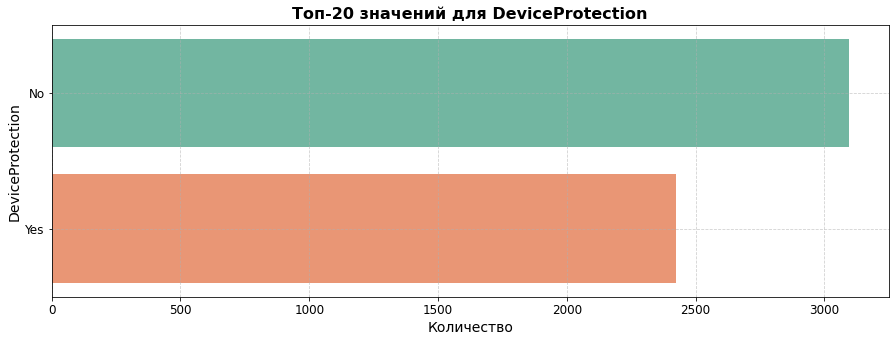

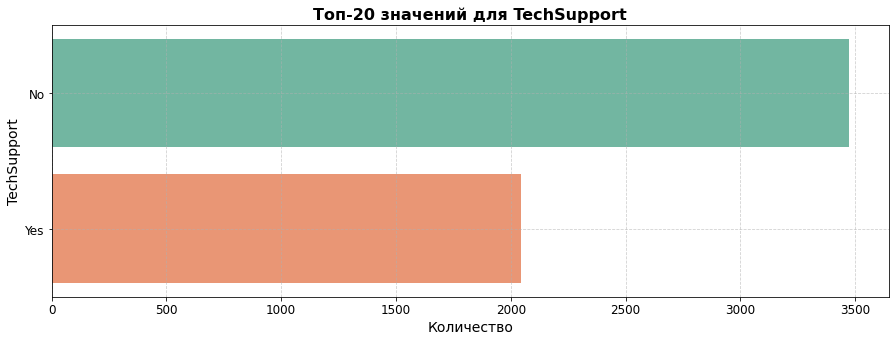

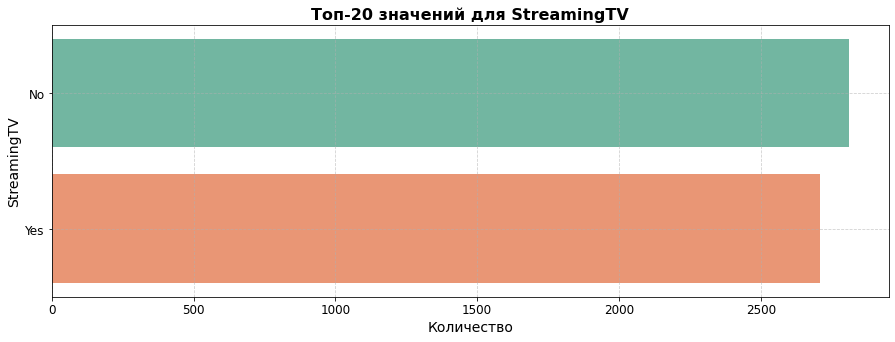

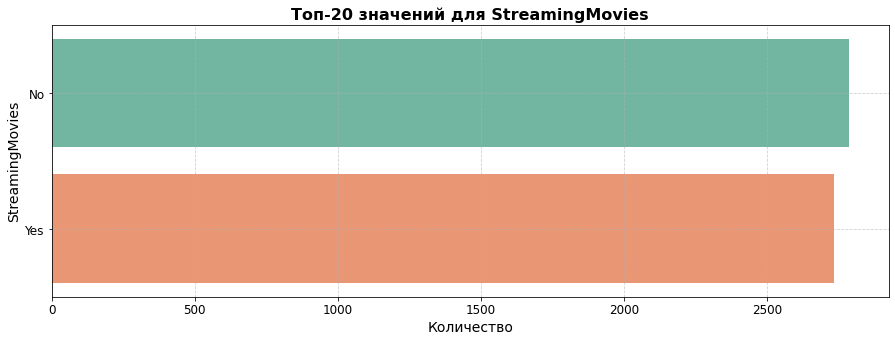

Сountplot для таблицы: phone


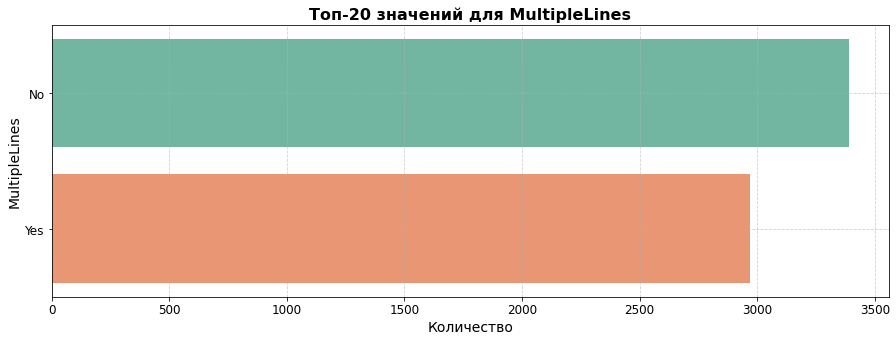

In [211]:
for tabel in table_names:
    print(f'Сountplot для таблицы: {tabel}')
    plot_countplot_in_batches(tabel, batch_size=5, drop_columns=['customerID', 'CustomerId'])

Итак, на основании графиков можно сделать несколько выводов.

Принадлежность к полу распределена в данных равномерно. Пожилых чуть более тысячи. Партнеры есть почти у половины клиентов. Дети чаще всего отсутствуют. Подключены клиенты чаще всего по оптоволокну. Дополнительные услуги у клиентов по услугам интернета чаще не подключены. По телефонии клиенты чаще пользуются однопоточной линией.

Приступим к объединению таблиц.

## Объединение таблиц и предобработка данных

Напишем запрос, чтоб объеденить наши таблицы:

In [212]:
query = """
SELECT c.customerID AS id,
       BeginDate AS begin_date,
       EndDate AS end_date,
       Type AS type,
       PaperlessBilling AS paper_less_billing,
       PaymentMethod AS payment_method,
       MonthlyCharges AS monthly_carges,
       TotalCharges AS total_charges,
       gender,
       SeniorCitizen AS senior_citizen,
       Partner AS partner,
       Dependents AS dependents,
       InternetService AS internet_service,
       OnlineSecurity AS online_security,
       OnlineBackup AS online_backup,
       DeviceProtection AS device_protection,
       TechSupport AS tech_support,
       StreamingTV AS streaming_tv,
       StreamingMovies AS streaming_movies,
       MultipleLines AS multiple_lines
FROM contract c
LEFT JOIN personal p ON c.customerID=p.customerID
LEFT JOIN internet i ON c.customerID=i.customerID
LEFT JOIN phone ph ON c.customerID=ph.customerId
"""

In [213]:
df = execute_query(query)

In [214]:
display(df.head())
display(df.info())

,id,begin_date,end_date,type,paper_less_billing,payment_method,monthly_carges,total_charges,gender,senior_citizen,partner,dependents,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04,Female,0,Yes,No,DSL,No,Yes,No,No,No,No,None
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84,Male,0,No,No,DSL,Yes,No,Yes,No,No,No,No
2,3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.85,226.17,Male,0,No,No,DSL,Yes,Yes,No,No,No,No,No
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.3,1960.6,Male,0,No,No,DSL,Yes,No,Yes,Yes,No,No,None
4,9237-HQITU,2019-09-01,No,Month-to-month,Yes,Electronic check,70.7,353.5,Female,0,No,No,Fiber optic,No,No,No,No,No,No,No


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  7043 non-null   object
 1   begin_date          7043 non-null   object
 2   end_date            7043 non-null   object
 3   type                7043 non-null   object
 4   paper_less_billing  7043 non-null   object
 5   payment_method      7043 non-null   object
 6   monthly_carges      7043 non-null   object
 7   total_charges       7043 non-null   object
 8   gender              7043 non-null   object
 9   senior_citizen      7043 non-null   object
 10  partner             7043 non-null   object
 11  dependents          7043 non-null   object
 12  internet_service    5517 non-null   object
 13  online_security     5517 non-null   object
 14  online_backup       5517 non-null   object
 15  device_protection   5517 non-null   object
 16  tech_support        5517

None

Для начала обработаем наши колонки. У нас везде тип object. Сначала приведем колонку с датами к виду datetime. Т.к. в колонке с окончанием есть буквенные значения - создадим функцию:

In [215]:
def convert_to_datetime(df, column_name):
    try:
        # Заменяем 'NO' на пустые строки, чтобы избежать ошибок преобразования
        df[column_name] = df[column_name].replace('NO', '') # or pd.NaT if you prefer NaT

        # Преобразуем столбец в datetime, игнорируя ошибки
        df[column_name] = pd.to_datetime(df[column_name], errors='coerce')

        return df

    except KeyError as e:
        print(f"Ошибка: столбец '{column_name}' не найден в DataFrame. {e}")
        return df

    except Exception as e:
        print(f"Ошибка при преобразовании столбца '{column_name}' в datetime: {e}")
        return df

In [216]:
df = convert_to_datetime(df, 'begin_date')
df = convert_to_datetime(df, 'end_date')

In [217]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id                  7043 non-null   object        
 1   begin_date          7043 non-null   datetime64[ns]
 2   end_date            1101 non-null   datetime64[ns]
 3   type                7043 non-null   object        
 4   paper_less_billing  7043 non-null   object        
 5   payment_method      7043 non-null   object        
 6   monthly_carges      7043 non-null   object        
 7   total_charges       7043 non-null   object        
 8   gender              7043 non-null   object        
 9   senior_citizen      7043 non-null   object        
 10  partner             7043 non-null   object        
 11  dependents          7043 non-null   object        
 12  internet_service    5517 non-null   object        
 13  online_security     5517 non-null   object      

None

Отлично, теперь преобразуем наши колонки с информацией о расходах за месяц и общих расходах абонента к количественному виду.

In [218]:
if pd.api.types.is_string_dtype(df['monthly_carges']):
    df['monthly_carges'] = pd.to_numeric(df['monthly_carges'].str.replace(' ', ''), errors='coerce')

if pd.api.types.is_string_dtype(df['total_charges']):
    df['total_charges'] = pd.to_numeric(df['total_charges'].str.replace(' ', ''), errors='coerce')


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id                  7043 non-null   object        
 1   begin_date          7043 non-null   datetime64[ns]
 2   end_date            1101 non-null   datetime64[ns]
 3   type                7043 non-null   object        
 4   paper_less_billing  7043 non-null   object        
 5   payment_method      7043 non-null   object        
 6   monthly_carges      7043 non-null   float64       
 7   total_charges       7032 non-null   float64       
 8   gender              7043 non-null   object        
 9   senior_citizen      7043 non-null   object        
 10  partner             7043 non-null   object        
 11  dependents          7043 non-null   object        
 12  internet_service    5517 non-null   object        
 13  online_security     5517 non-null   object      

Отлично! Теперь изучим их, построив гистограммы. Создадим функцию:

In [219]:
def hist_num(data_row, name_hist, name_box, name_y):
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,5))

    data_row.plot(kind='hist', bins=30, ax=axes[0], grid=True)
    axes[0].set_title(name_hist, fontsize = 12)
    axes[0].set_xlabel(name_y)
    axes[0].set_ylabel('Количество')

    plt.grid(True)
    
    data_row.plot(kind='box', ax=axes[1], grid=True)
    axes[1].set_title(name_box, fontsize = 12)
    axes[1].set_xlabel(name_y)
    axes[1].set_ylabel('Количество')
    fig.tight_layout()
    plt.show()

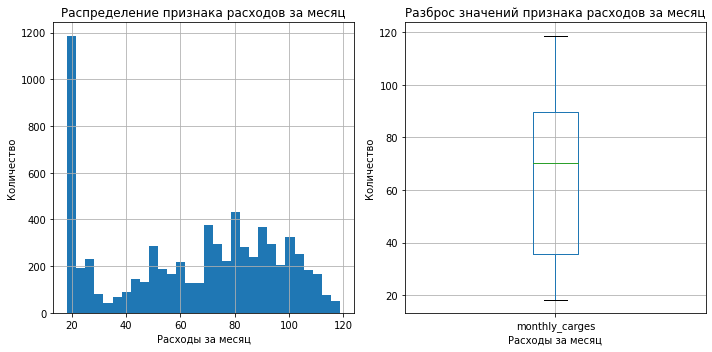

In [220]:
hist_num(df['monthly_carges'], 'Распределение признака расходов за месяц', 'Разброс значений признака расходов за месяц', 'Расходы за месяц')

Как таковых выбросов нет. Данные о расходах за месяц часто находятся в рамках 40 - 100 долларов. У части клиентов (около 1200 расходы не превышают 20 долларов).

Изучим данные об общих расходах:

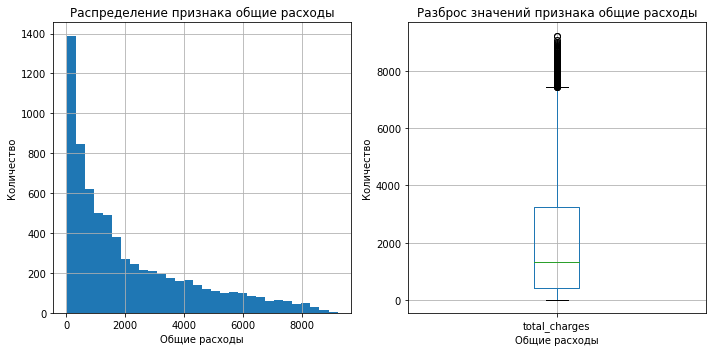

In [221]:
hist_num(df['total_charges'], 'Распределение признака общие расходы', 'Разброс значений признака общие расходы', 'Общие расходы')

А вот с обищими расходами интереснее. Есть выборосы выше 8 тысяч долларов. Это можно обосновать долгим сроком договора по клиенту. Не будем их исключать, т.к. это важный признак того, что, возможно, клиент, который оставил больше денег - не захочет разрывать договор. 

Итак, выведем из колонки с информацией о дате разрыва договора целевой признак:

In [222]:
df['client_left'] = df['end_date'].apply(lambda x: 0 if pd.isna(x) else 1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id                  7043 non-null   object        
 1   begin_date          7043 non-null   datetime64[ns]
 2   end_date            1101 non-null   datetime64[ns]
 3   type                7043 non-null   object        
 4   paper_less_billing  7043 non-null   object        
 5   payment_method      7043 non-null   object        
 6   monthly_carges      7043 non-null   float64       
 7   total_charges       7032 non-null   float64       
 8   gender              7043 non-null   object        
 9   senior_citizen      7043 non-null   object        
 10  partner             7043 non-null   object        
 11  dependents          7043 non-null   object        
 12  internet_service    5517 non-null   object        
 13  online_security     5517 non-null   object      

Изучим наш целевой признак, постров гистограмму:

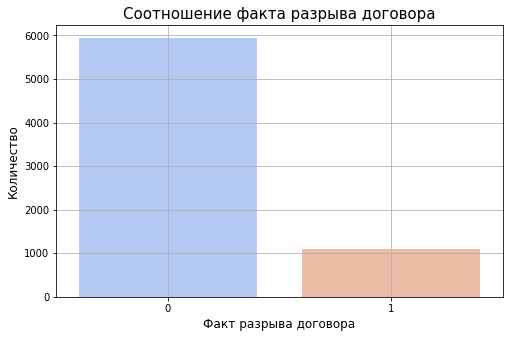

In [223]:
plt.figure(figsize=(8, 5))
sns.countplot(x='client_left', data=df, palette='coolwarm')
plt.title('Соотношение факта разрыва договора', fontsize=15)
plt.xlabel('Факт разрыва договора', fontsize=12)
plt.ylabel('Количество', fontsize=12)
plt.grid(True)
plt.show()

Итак, целевого признака у нас мало. Из 7 тысяч записей 6 тысяч - текущие клиенты, 1 тысяча - бывшие. Будем работать с тем, что имеем. 

Выведем новый признак: длительность пользования услугами.

In [224]:
df['end_date'].fillna('2020-02-01', inplace=True)
df = convert_to_datetime(df, 'end_date')
df['days'] = (df['end_date'] - df['begin_date']).dt.days    

In [225]:
df.head()

,id,begin_date,end_date,type,paper_less_billing,payment_method,monthly_carges,total_charges,gender,senior_citizen,partner,dependents,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines,client_left,days
0,7590-VHVEG,2020-01-01,2020-02-01,Month-to-month,Yes,Electronic check,29.85,31.04,Female,0,Yes,No,DSL,No,Yes,No,No,No,No,None,0,31
1,5575-GNVDE,2017-04-01,2020-02-01,One year,No,Mailed check,56.95,2071.84,Male,0,No,No,DSL,Yes,No,Yes,No,No,No,No,0,1036
2,3668-QPYBK,2019-10-01,2020-02-01,Month-to-month,Yes,Mailed check,53.85,226.17,Male,0,No,No,DSL,Yes,Yes,No,No,No,No,No,0,123
3,7795-CFOCW,2016-05-01,2020-02-01,One year,No,Bank transfer (automatic),42.30,1960.60,Male,0,No,No,DSL,Yes,No,Yes,Yes,No,No,None,0,1371
4,9237-HQITU,2019-09-01,2020-02-01,Month-to-month,Yes,Electronic check,70.70,353.50,Female,0,No,No,Fiber optic,No,No,No,No,No,No,No,0,153


Итак, новый признак получен. Избавимся от колонок с датами, чтобы избежать утечки данных при обучении:

In [226]:
df = df.drop(['begin_date','end_date'], axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  7043 non-null   object 
 1   type                7043 non-null   object 
 2   paper_less_billing  7043 non-null   object 
 3   payment_method      7043 non-null   object 
 4   monthly_carges      7043 non-null   float64
 5   total_charges       7032 non-null   float64
 6   gender              7043 non-null   object 
 7   senior_citizen      7043 non-null   object 
 8   partner             7043 non-null   object 
 9   dependents          7043 non-null   object 
 10  internet_service    5517 non-null   object 
 11  online_security     5517 non-null   object 
 12  online_backup       5517 non-null   object 
 13  device_protection   5517 non-null   object 
 14  tech_support        5517 non-null   object 
 15  streaming_tv        5517 non-null   object 
 16  stream

Итак, у нас остались пропуски в информации о подключенных услугах. Т.к. данных по клиенту нет - будем считать, что и услуг у клиента этих нет. Но добавим новый признак - "No phone" или "No internet". Иначе компанию можно считать ненадежной, если она не ведет учет подключенных услуг. Заменим пропуски. В случае с типом подключения будем исходить из информации о налаичии телефонной связи  у клиента. Если она есть - проставим DSL, если нет - оптоволокно:

In [227]:
df['internet_service'] = np.where(df['multiple_lines'].isna(), 'Fiber optic', np.where(df['internet_service'].isna(), 'DSL', df['multiple_lines']))

In [228]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  7043 non-null   object 
 1   type                7043 non-null   object 
 2   paper_less_billing  7043 non-null   object 
 3   payment_method      7043 non-null   object 
 4   monthly_carges      7043 non-null   float64
 5   total_charges       7032 non-null   float64
 6   gender              7043 non-null   object 
 7   senior_citizen      7043 non-null   object 
 8   partner             7043 non-null   object 
 9   dependents          7043 non-null   object 
 10  internet_service    7043 non-null   object 
 11  online_security     5517 non-null   object 
 12  online_backup       5517 non-null   object 
 13  device_protection   5517 non-null   object 
 14  tech_support        5517 non-null   object 
 15  streaming_tv        5517 non-null   object 
 16  stream

И, наконец, заполним значением "No phone" или "No internet" в информации об всех услугах, а информацию о сумме заполним 0.0:

In [229]:
df['total_charges'].fillna(0.0, inplace=True)
df['online_security'].fillna("No internet", inplace=True)
df['online_backup'].fillna("No internet", inplace=True)
df['device_protection'].fillna("No internet", inplace=True)
df['tech_support'].fillna("No internet", inplace=True)
df['streaming_tv'].fillna("No internet", inplace=True)
df['streaming_movies'].fillna("No internet", inplace=True)
df['multiple_lines'].fillna("No phone", inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  7043 non-null   object 
 1   type                7043 non-null   object 
 2   paper_less_billing  7043 non-null   object 
 3   payment_method      7043 non-null   object 
 4   monthly_carges      7043 non-null   float64
 5   total_charges       7043 non-null   float64
 6   gender              7043 non-null   object 
 7   senior_citizen      7043 non-null   object 
 8   partner             7043 non-null   object 
 9   dependents          7043 non-null   object 
 10  internet_service    7043 non-null   object 
 11  online_security     7043 non-null   object 
 12  online_backup       7043 non-null   object 
 13  device_protection   7043 non-null   object 
 14  tech_support        7043 non-null   object 
 15  streaming_tv        7043 non-null   object 
 16  stream

Итак, на этапе объединения таблиц и предобработки данных был написан запрос к БД и данные были слиты в один датасет. Далее мы обработали типы колонок и привели их правильному типу. Следом мы вывели целевой признак по факту отказа от услуг - если дата есть - значит клиент отказался. Также мы вывели признак о длительности пользования услугами и удалили колонки с информацией о датах. И, наконец, заполнили пропуски: в случае с типом подключения будем исходить из информации о налаичии телефонной связи у клиента. Если она есть - проставим DSL, если нет - оптоволокно, а  информацию об всех услугах заполнили значением "No internet" или "No phone".

Можно приступать к корреляционному анализу.

## Корреляционный анлаиз

Проведем корреляционный анализ. Так как в данных присутствуют категориальные значения, для построения матрицы корреляции будем использовать библиотеку phik:

In [230]:
interval_cols = ['days', 'monthly_carges', 'total_charges']
corr_df = df.drop(['client_left', 'id'], axis=1)
corr_matrix = corr_df.phik_matrix(interval_cols=interval_cols)
corr_matrix.round(2)

,type,paper_less_billing,payment_method,monthly_carges,total_charges,gender,senior_citizen,partner,dependents,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines,days
type,1.00,0.11,0.28,0.39,0.47,0.00,0.09,0.18,0.15,0.21,0.64,0.58,0.63,0.67,0.55,0.55,0.24,0.63
paper_less_billing,0.11,1.00,0.37,0.47,0.20,0.00,0.24,0.01,0.17,0.50,0.21,0.20,0.20,0.20,0.20,0.20,0.10,0.03
payment_method,0.28,0.37,1.00,0.40,0.34,0.00,0.29,0.24,0.22,0.53,0.32,0.29,0.30,0.32,0.28,0.29,0.17,0.35
monthly_carges,0.39,0.47,0.40,1.00,0.71,0.01,0.30,0.20,0.18,0.86,0.81,0.82,0.83,0.82,0.86,0.86,0.71,0.39
total_charges,0.47,0.20,0.34,0.71,1.00,0.00,0.14,0.38,0.08,0.51,0.52,0.55,0.56,0.53,0.56,0.55,0.47,0.85
gender,0.00,0.00,0.00,0.01,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
senior_citizen,0.09,0.24,0.29,0.30,0.14,0.00,1.00,0.02,0.32,0.32,0.13,0.11,0.11,0.14,0.11,0.11,0.09,0.06
partner,0.18,0.01,0.24,0.20,0.38,0.00,0.02,1.00,0.65,0.19,0.09,0.09,0.10,0.08,0.08,0.08,0.09,0.45
dependents,0.15,0.17,0.22,0.18,0.08,0.00,0.32,0.65,1.00,0.21,0.12,0.10,0.09,0.11,0.09,0.08,0.01,0.20
internet_service,0.21,0.50,0.53,0.86,0.51,0.00,0.32,0.19,0.21,1.00,0.68,0.68,0.68,0.68,0.69,0.69,0.88,0.27


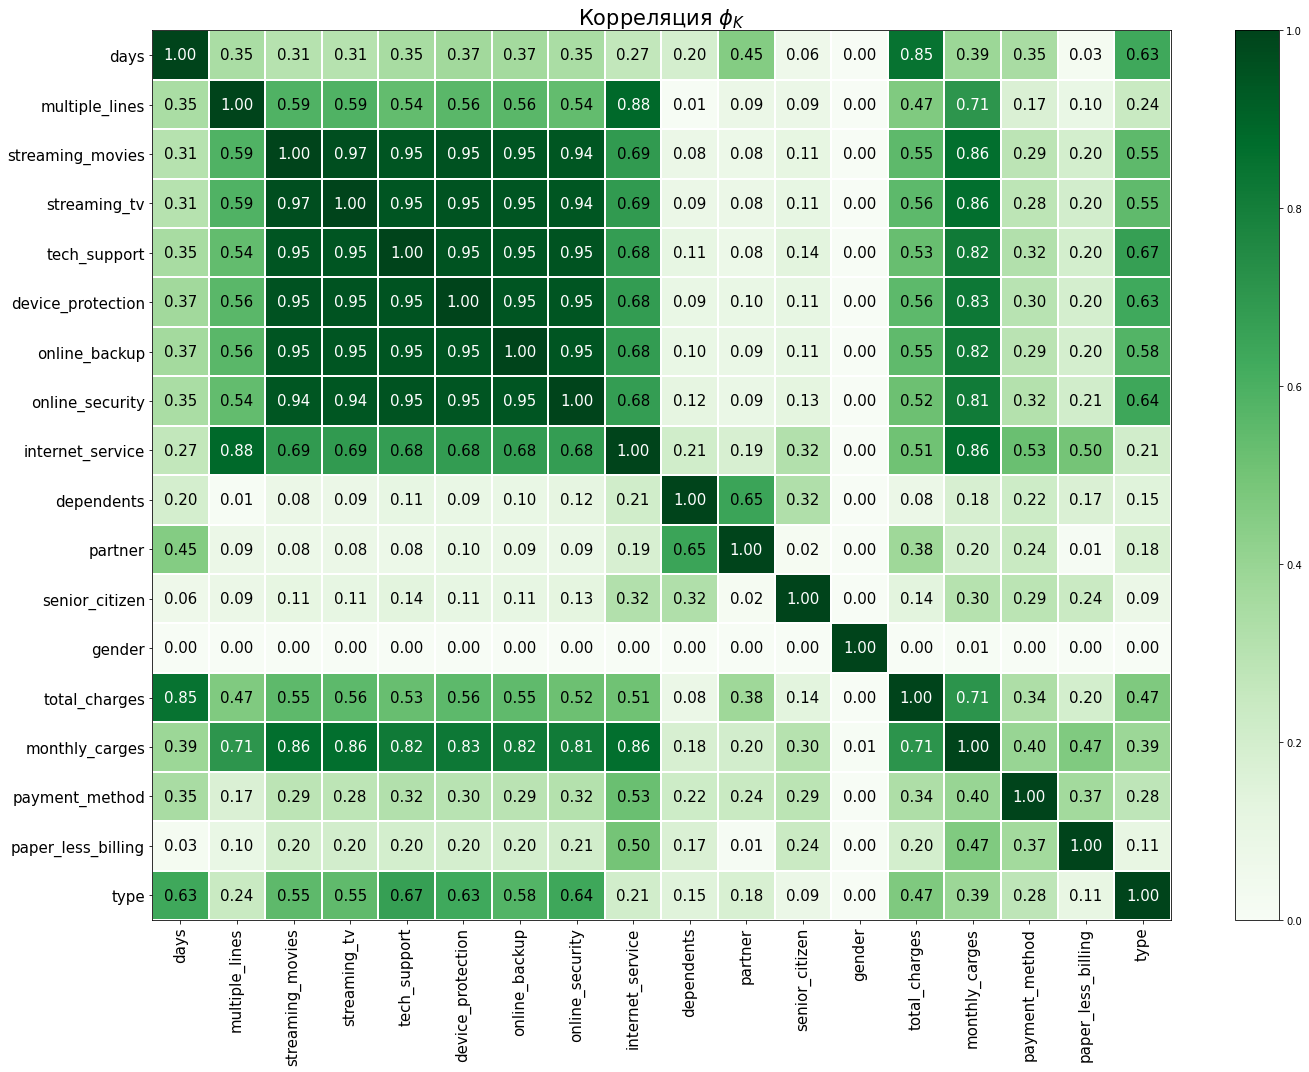

In [231]:
plot_correlation_matrix(
    corr_matrix.values,
    x_labels=corr_matrix.columns,
    y_labels=corr_matrix.index,
    vmin=0, vmax=1, color_map='Greens', 
    title=r'Корреляция $\phi_K$',  
    fontsize_factor=1.5,  
    figsize=(20, 15)
)

Построим хитмап отдельно для каждого класса, так как у нас несколько класов целевой переменной. Это поможет визуальному анализу того, какие признаки оказывают влияние на каждый из классов. Проанализировав отдельные хитмапы, мы сможешь выделить те признаки, которые оказывают влияние внутри каждого из классов таргета. Это может помочь в понимании важности определенных характеристик для принятия решения моделью.

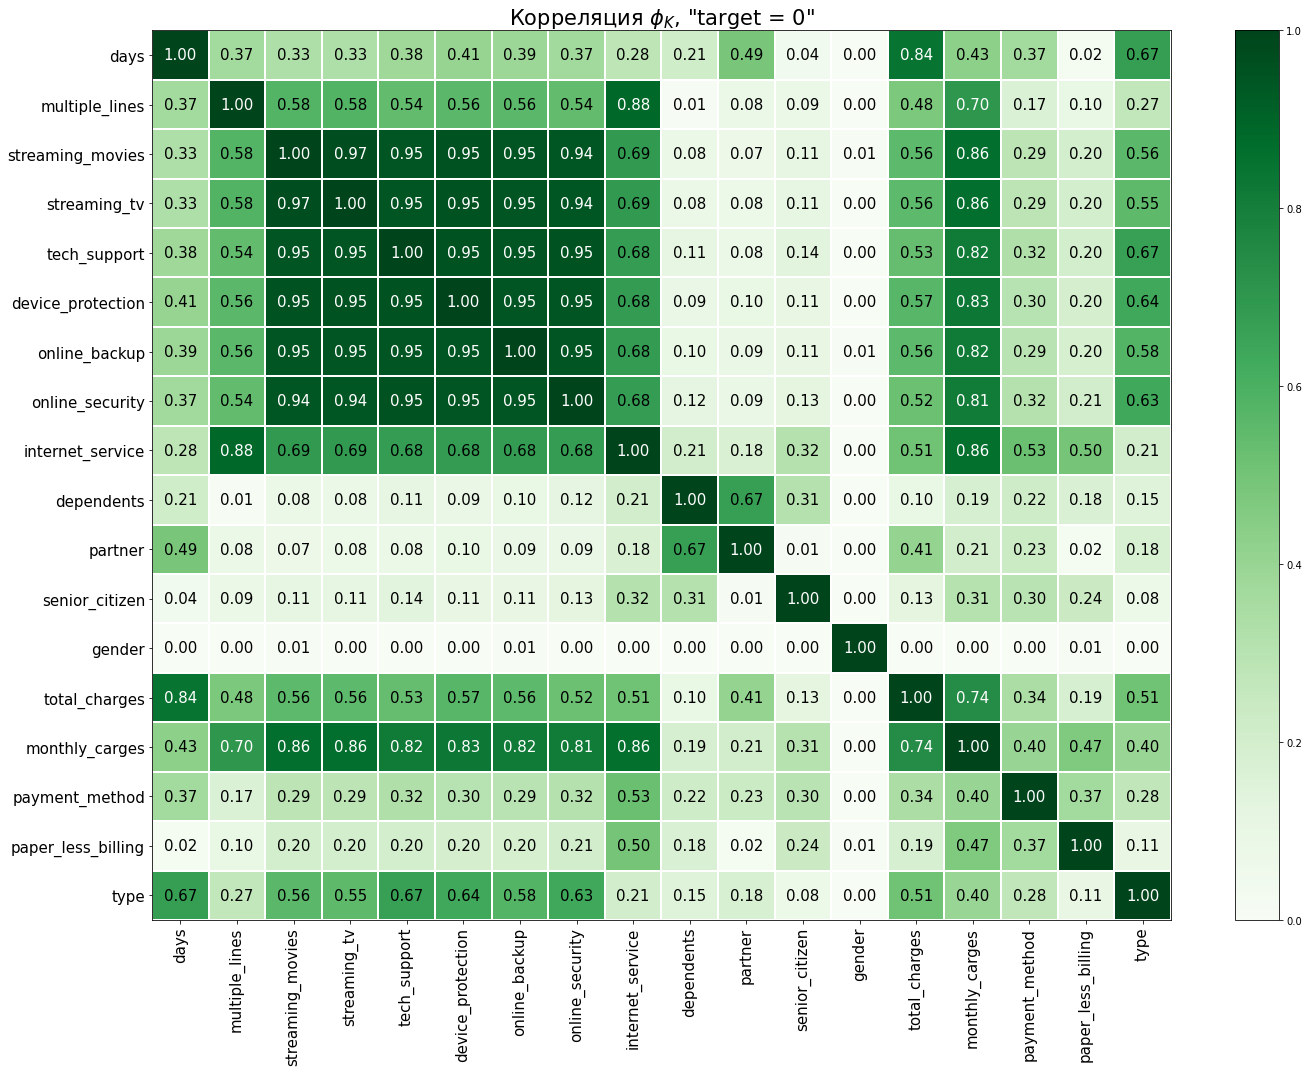

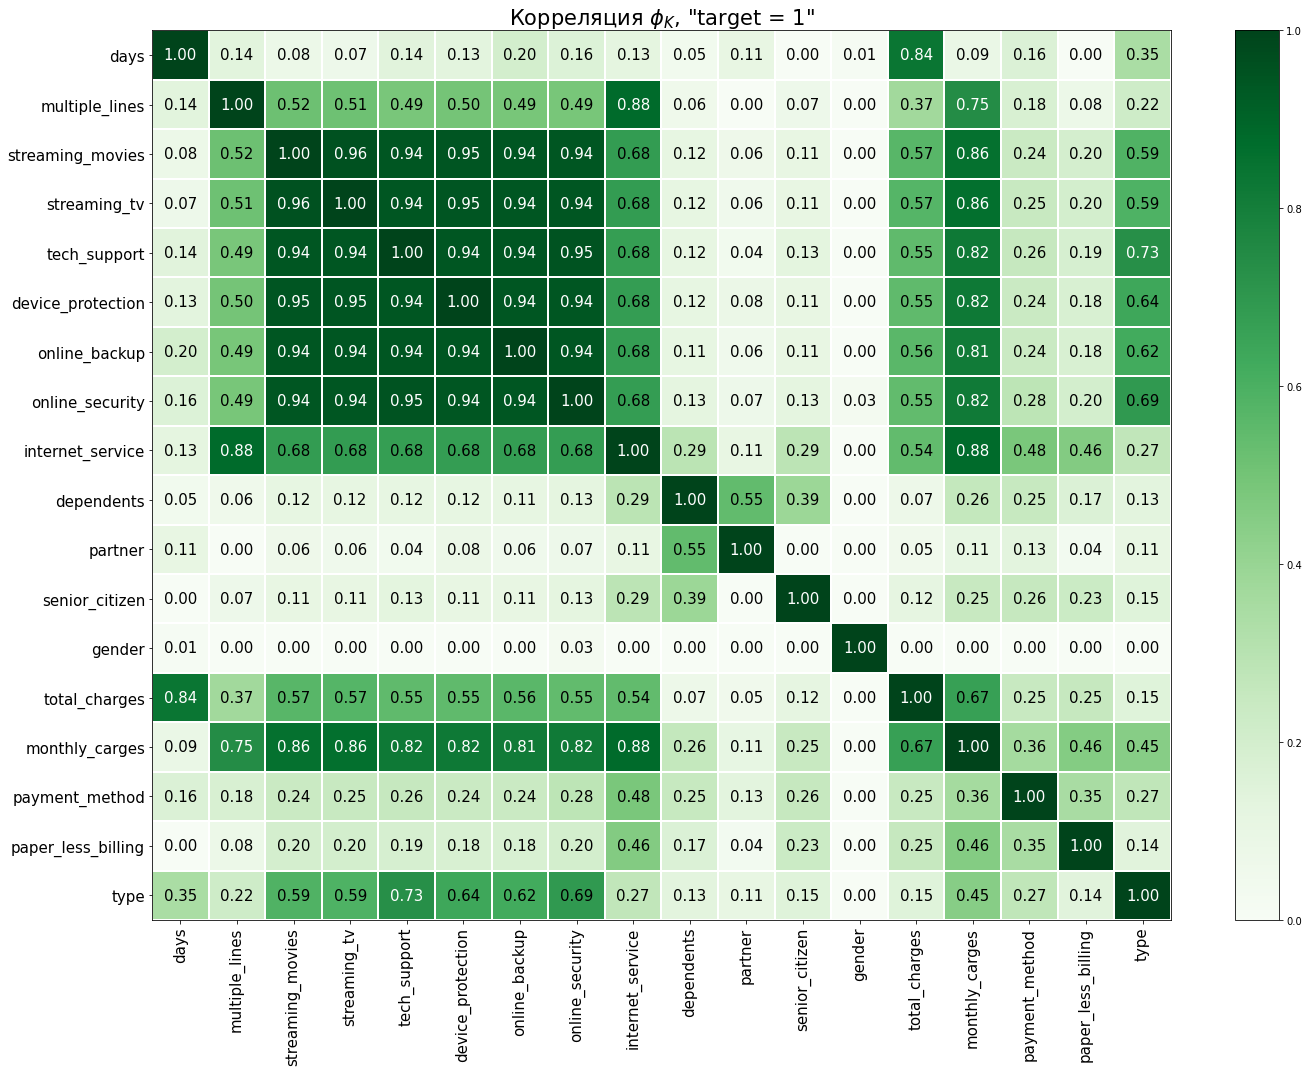

In [232]:
df_target_0 = df[df['client_left'] == 0]
df_target_1 = df[df['client_left'] == 1]

# Вычисление матриц корреляции для каждого подмножества данных
corr_matrix_0 = df_target_0.drop(columns=['client_left', 'id']).phik_matrix(interval_cols=interval_cols);
corr_matrix_1 = df_target_1.drop(columns=['client_left', 'id']).phik_matrix(interval_cols=interval_cols);

# Построение отдельных хитмапов для каждой матрицы корреляции
plot_correlation_matrix(
    corr_matrix_0.values,
    x_labels=corr_matrix_0.columns,
    y_labels=corr_matrix_0.index,
    vmin=0, vmax=1, color_map='Greens', 
    title=r'Корреляция $\phi_K$, "target = 0"',  
    fontsize_factor=1.5,  
    figsize=(20, 15)
);

plot_correlation_matrix(
    corr_matrix_1.values,
    x_labels=corr_matrix_1.columns,
    y_labels=corr_matrix_1.index,
    vmin=0, vmax=1, color_map='Greens', 
    title=r'Корреляция $\phi_K$, "target = 1"',  
    fontsize_factor=1.5,  
    figsize=(20, 15)
);

Анализ матриц корреляции выявил различия в связи признаков с целевой переменной (client_left) в зависимости от её значения (1 или 0):

*   `monthly_charges`: Более сильная корреляция с `internet_service` при `target = 1` (0.88) по сравнению с `target = 0` (0.86) указывает на то, что от типа подключения будет зависеть и стоимость.

*   `monthly_charges`: Одинаково высокая корреляция с `streaming_movies` и `streaming_tv` при `target = 0` (0.86) относительно `target = 0` (0.86). Что может говорить о том, что чем больше клиент платит за услуги, тем реже он планирует уйти.

*   `multiple_lines`: Одинаково высоко коррелирует с `internet_service` при `target = 1` (0.88) и при `target = 0` (0.88), что может указывать на то, что от типа подключения интернета зависит, есть ли услуги телефона у человека, что логично. Удалять этот признак мы не будем.
* `days` одинаково сильно коррелирует с `total_charges` и при `target = 1` (0.84), и при `target = 0` (0.84), что подчеркивает что, чем больше люди пользуются услугами, тем больше денег они оставили компании.

Итак, можно приступать к подготовке данных для обучения.

In [233]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  7043 non-null   object 
 1   type                7043 non-null   object 
 2   paper_less_billing  7043 non-null   object 
 3   payment_method      7043 non-null   object 
 4   monthly_carges      7043 non-null   float64
 5   total_charges       7043 non-null   float64
 6   gender              7043 non-null   object 
 7   senior_citizen      7043 non-null   object 
 8   partner             7043 non-null   object 
 9   dependents          7043 non-null   object 
 10  internet_service    7043 non-null   object 
 11  online_security     7043 non-null   object 
 12  online_backup       7043 non-null   object 
 13  device_protection   7043 non-null   object 
 14  tech_support        7043 non-null   object 
 15  streaming_tv        7043 non-null   object 
 16  stream

## Подготовка данных для обучения

Начнем с того, что разделим наши признаки для кодирования:

In [251]:
ohe_columns = [ 'type', 'paper_less_billing', 'payment_method', 'senior_citizen', 'partner', 'dependents', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'multiple_lines']
num_columns = ['days', 'monthly_carges', 'total_charges']

Разделим выборки на тренировочные и тестовые:

In [252]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(['id', 'client_left', 'gender'], axis=1),
    df['client_left'],
    test_size = TEST_SIZE, 
    random_state = RANDOM_STATE,
    stratify = df['client_left'])
print(X_train.shape, X_test.shape)
y_train.shape, y_test.shape

(5282, 17) (1761, 17)


((5282,), (1761,))

Теперь разделим выборки на валидационную и тренировочную:

Создадим пайплайн для моделей HistGradientBoostingClassifier и RandomForestClassifier.

In [253]:
def pipe_line(ohe_columns, num_columns):
    global pipe_final
    
    ohe_pipe = Pipeline(
        [
            (
                'simpleImputer_ohe', 
                SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='unknown')  
            ),
            (
                'ohe', 
                OneHotEncoder(drop='first', handle_unknown='error'))
        ]
    )

    data_preprocessor = ColumnTransformer(
        [
            ('ohe', ohe_pipe, ohe_columns),  
            ('num', MinMaxScaler(), num_columns)
        ],
        remainder='passthrough'  
    )

    pipe_final = Pipeline([
        ('preprocessor', data_preprocessor),
        ('models', LogisticRegression()) 
    ])
    
pipe_line(ohe_columns, num_columns)

param_grid = [
    {
    'models': [CatBoostClassifier()],
    'models__iterations': [100, 200, 300], # Количество деревьев
    'models__depth': [4, 6, 8], # Глубина деревьев
    'models__learning_rate': [0.03, 0.1, 0.3], # Скорость обучения
    'models__l2_leaf_reg': [1, 3, 5] # L2 регуляризация
    },
   {
    'models': [RandomForestClassifier()],
    'models__n_estimators': [50, 100, 200], # Количество деревьев
    'models__max_depth': [None, 10, 20, 30], # Максимальная глубина деревьев
    'models__min_samples_split': [2, 5, 10], # Минимальное количество выборок для разделения узла
    'models__min_samples_leaf': [1, 2, 4] # Минимальное количество выборок в листе
    }
]

Итак, данные подготовлены, можно приступать к обучению нашей модели.

## Обучение моделей

Приступим к нашему обучению:

In [254]:
random_search = RandomizedSearchCV(
    pipe_final, 
    param_grid, 
    n_iter=20,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

random_search.fit(X_train, y_train)

0:	learn: 0.5235374	total: 1.5ms	remaining: 298ms
1:	learn: 0.4395821	total: 3.26ms	remaining: 323ms
2:	learn: 0.4034114	total: 4.69ms	remaining: 308ms
3:	learn: 0.3775573	total: 6.07ms	remaining: 298ms
4:	learn: 0.3623049	total: 7.53ms	remaining: 294ms
5:	learn: 0.3514017	total: 8.91ms	remaining: 288ms
6:	learn: 0.3472915	total: 10.2ms	remaining: 281ms
7:	learn: 0.3404272	total: 11.7ms	remaining: 280ms
8:	learn: 0.3367801	total: 13ms	remaining: 277ms
9:	learn: 0.3327525	total: 14.4ms	remaining: 273ms
10:	learn: 0.3297450	total: 15.8ms	remaining: 272ms
11:	learn: 0.3254249	total: 17.1ms	remaining: 268ms
12:	learn: 0.3238320	total: 18.4ms	remaining: 265ms
13:	learn: 0.3221269	total: 19.6ms	remaining: 261ms
14:	learn: 0.3192346	total: 21ms	remaining: 259ms
15:	learn: 0.3179495	total: 22.2ms	remaining: 256ms
16:	learn: 0.3171366	total: 23.6ms	remaining: 254ms
17:	learn: 0.3159167	total: 24.9ms	remaining: 252ms
18:	learn: 0.3145517	total: 26.3ms	remaining: 251ms
19:	learn: 0.3135364	total:

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('ohe',
                                                                               Pipeline(steps=[('simpleImputer_ohe',
                                                                                                SimpleImputer(fill_value='unknown',
                                                                                                              strategy='constant')),
                                                                                               ('ohe',
                                                                                                OneHotEncoder(drop='first'))]),
                                                                               ['type',
                                     

In [255]:
print('Лучшая модель и её параметры:\n\n', random_search.best_estimator_)
print ('Метрика лучшей модели на тренировочной выборке:', random_search.best_score_)
print('Параметры лучшей модели:', random_search.best_params_)

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(fill_value='unknown',
                                                                                 strategy='constant')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first'))]),
                                                  ['type', 'paper_less_billing',
                                                   'payment_method',
                                                   'senior_citizen', 'partner',
                                                   'dependents',
                                                   'int

In [256]:
result = pd.DataFrame(random_search.cv_results_)
result[
    ['param_models', 'mean_test_score', 'params']
].sort_values('mean_test_score', ascending=False).head(10)

,param_models,mean_test_score,params
1,<catboost.core.CatBoostClassifier object at 0x7f990b676af0>,0.911929,"{'models__learning_rate': 0.3, 'models__l2_leaf_reg': 3, 'models__iterations': 200, 'models__depth': 4, 'models': <catboost.core.CatBoostClassifier object at 0x7f990b676af0>}"
14,<catboost.core.CatBoostClassifier object at 0x7f990b676af0>,0.890190,"{'models__learning_rate': 0.3, 'models__l2_leaf_reg': 1, 'models__iterations': 100, 'models__depth': 6, 'models': <catboost.core.CatBoostClassifier object at 0x7f990b676af0>}"
8,<catboost.core.CatBoostClassifier object at 0x7f990b676af0>,0.871184,"{'models__learning_rate': 0.1, 'models__l2_leaf_reg': 1, 'models__iterations': 300, 'models__depth': 8, 'models': <catboost.core.CatBoostClassifier object at 0x7f990b676af0>}"
9,<catboost.core.CatBoostClassifier object at 0x7f990b676af0>,0.867389,"{'models__learning_rate': 0.1, 'models__l2_leaf_reg': 3, 'models__iterations': 200, 'models__depth': 8, 'models': <catboost.core.CatBoostClassifier object at 0x7f990b676af0>}"
16,<catboost.core.CatBoostClassifier object at 0x7f990b676af0>,0.865345,"{'models__learning_rate': 0.3, 'models__l2_leaf_reg': 5, 'models__iterations': 100, 'models__depth': 8, 'models': <catboost.core.CatBoostClassifier object at 0x7f990b676af0>}"
17,<catboost.core.CatBoostClassifier object at 0x7f990b676af0>,0.863946,"{'models__learning_rate': 0.1, 'models__l2_leaf_reg': 1, 'models__iterations': 200, 'models__depth': 8, 'models': <catboost.core.CatBoostClassifier object at 0x7f990b676af0>}"
11,<catboost.core.CatBoostClassifier object at 0x7f990b676af0>,0.863235,"{'models__learning_rate': 0.3, 'models__l2_leaf_reg': 1, 'models__iterations': 200, 'models__depth': 8, 'models': <catboost.core.CatBoostClassifier object at 0x7f990b676af0>}"
15,<catboost.core.CatBoostClassifier object at 0x7f990b676af0>,0.834930,"{'models__learning_rate': 0.1, 'models__l2_leaf_reg': 5, 'models__iterations': 100, 'models__depth': 6, 'models': <catboost.core.CatBoostClassifier object at 0x7f990b676af0>}"
10,<catboost.core.CatBoostClassifier object at 0x7f990b676af0>,0.833739,"{'models__learning_rate': 0.03, 'models__l2_leaf_reg': 1, 'models__iterations': 200, 'models__depth': 6, 'models': <catboost.core.CatBoostClassifier object at 0x7f990b676af0>}"
4,<catboost.core.CatBoostClassifier object at 0x7f990b676af0>,0.831883,"{'models__learning_rate': 0.03, 'models__l2_leaf_reg': 3, 'models__iterations': 200, 'models__depth': 6, 'models': <catboost.core.CatBoostClassifier object at 0x7f990b676af0>}"


Итак, пока лучшей моделью является Catboost. Но перед оценкой на тестовой выборке необходимо оценить ещё и нейронную сеть.  Создадим её:

In [244]:
def pipe_line_1(ohe_columns, num_columns):
    ohe_pipe = Pipeline([
        ('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='unknown')),
        ('ohe', OneHotEncoder(drop='first', handle_unknown='error')) # sparse=False для совместимости с TensorFlow/Keras
    ])

    data_preprocessor = ColumnTransformer([
        ('ohe', ohe_pipe, ohe_columns),
        ('num', MinMaxScaler(), num_columns)
    ], remainder='passthrough') # 'passthrough' для остальных столбцов

    pipe_final = Pipeline([
        ('preprocessor', data_preprocessor),
        ('models', KerasClassifier(build_fn=create_model, verbose=0))
    ])
    return pipe_final
def create_model(learning_rate=0.001, num_neurons=16, input_shape=None):
    input_tensor = keras.Input(shape=input_shape)
    x = keras.layers.Dense(num_neurons, activation='relu')(input_tensor)
    output_tensor = keras.layers.Dense(1, activation='sigmoid')(x)
    model = keras.Model(inputs=input_tensor, outputs=output_tensor)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(name='roc_auc')]
    )
    return model
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', # Отслеживаем потери на валидации
    patience=3, # 3 эпохи без улучшений
    restore_best_weights=True # Восстанавливаем лучшие веса
)

In [245]:
pipe = pipe_line_1(ohe_columns, num_columns)
preprocessor = pipe.named_steps['preprocessor']
X_train_transformed = preprocessor.fit_transform(X_train)
input_shape = (X_train_transformed.shape[1],)
param_grid = {
    'models__learning_rate': [0.001, 0.01], 
    'models__num_neurons': [16, 32, 64], 
    'models__batch_size': [16, 32],        
    'models__epochs': [20, 50]              
}
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
model = KerasClassifier(build_fn=create_model, verbose=0, learning_rate=0.001, num_neurons=16, input_shape=input_shape)

pipe.set_params(models=model)

/tmp/ipykernel_48/630059237.py:14: DeprecationWarning: KerasClassifier is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead.
  ('models', KerasClassifier(build_fn=create_model, verbose=0))
/tmp/ipykernel_48/3121500838.py:12: DeprecationWarning: KerasClassifier is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead.
  model = KerasClassifier(build_fn=create_model, verbose=0, learning_rate=0.001, num_neurons=16, input_shape=input_shape)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(fill_value='unknown',
                                                                                 strategy='constant')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first'))]),
                                                  ['type', 'paper_less_billing',
                                                   'payment_method',
                                                   'senior_citizen', 'partner',
                                                   'dependents',
                                                   'internet_service',
                

In [246]:
grid = GridSearchCV(estimator=pipe, param_grid=param_grid, scoring='roc_auc', cv=kf, n_jobs=-1, return_train_score=True)
grid_result = grid.fit(X_train, y_train)

In [247]:
print(f"Лучшие параметры: {grid_result.best_params_}")
print(f"Лучший ROC-AUC: {grid_result.best_score_}")

Лучшие параметры: {'models__batch_size': 16, 'models__epochs': 20, 'models__learning_rate': 0.01, 'models__num_neurons': 16}
Лучший ROC-AUC: 0.8113302295943923


Итак, нейронная сеть несправилась даже на валидации с требованиями заказчика. Метрика составила 0.81. 

В таком случае для оценки обучения будем использовать модель Catboost. Расчитаем метрику лучшей модели на тестовой выборке:

In [257]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(['id', 'client_left', 'gender'], axis=1),
    df['client_left'],
    test_size = TEST_SIZE, 
    random_state = RANDOM_STATE,
    stratify = df['client_left'])

In [258]:
model_params = random_search.cv_results_['params'][1]
chosen_model_cat = random_search.estimator.set_params(**model_params)

In [260]:
chosen_model_cat.fit(X_train, y_train)

0:	learn: 0.5234817	total: 1.72ms	remaining: 342ms
1:	learn: 0.4466655	total: 3.34ms	remaining: 331ms
2:	learn: 0.3941666	total: 4.85ms	remaining: 319ms
3:	learn: 0.3668438	total: 6.46ms	remaining: 317ms
4:	learn: 0.3579919	total: 7.97ms	remaining: 311ms
5:	learn: 0.3500166	total: 9.55ms	remaining: 309ms
6:	learn: 0.3443909	total: 11.1ms	remaining: 305ms
7:	learn: 0.3384806	total: 12.6ms	remaining: 304ms
8:	learn: 0.3352799	total: 14.2ms	remaining: 302ms
9:	learn: 0.3307051	total: 15.7ms	remaining: 298ms
10:	learn: 0.3274412	total: 17.1ms	remaining: 294ms
11:	learn: 0.3262826	total: 18.7ms	remaining: 292ms
12:	learn: 0.3238847	total: 20.1ms	remaining: 289ms
13:	learn: 0.3223650	total: 21.6ms	remaining: 286ms
14:	learn: 0.3203021	total: 23.1ms	remaining: 285ms
15:	learn: 0.3180747	total: 24.5ms	remaining: 281ms
16:	learn: 0.3169077	total: 26ms	remaining: 280ms
17:	learn: 0.3155521	total: 27.4ms	remaining: 277ms
18:	learn: 0.3143079	total: 29ms	remaining: 276ms
19:	learn: 0.3133649	total

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(fill_value='unknown',
                                                                                 strategy='constant')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first'))]),
                                                  ['type', 'paper_less_billing',
                                                   'payment_method',
                                                   'senior_citizen', 'partner',
                                                   'dependents',
                                                   'internet_service',
                

In [261]:
y_pred_proba = chosen_model_cat.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)

In [262]:
print(f"ROC AUC: {roc_auc}")

ROC AUC: 0.9258020310779396


Для того, чтобы лучше интерпретировать модель расчитаем и accuracy.

In [266]:
y_pred = (y_pred_proba > 0.5).astype(int)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.9267461669505963


Итак, метрика на тестовой выборке составила 0.92, что удовлетворяет условия заказчика. Проверим модель на адекватность через классификатор DummyClassifier:

In [263]:
dummy_model = DummyClassifier(random_state=RANDOM_STATE)

dummy_model.fit(X_train, y_train)

dummy_model_preds = dummy_model.predict(X_test)

dummy_model_probas = dummy_model.predict_proba(X_test)[:,1]

print('Метрики Dummy модели:')

dummy_roc = roc_auc_score(y_test, dummy_model_probas)
print('ROC-AUC =', round(dummy_roc, 2))

Метрики Dummy модели:
ROC-AUC = 0.5


Проверка модели на адекватность с использованием DummyClassifier позволяет оценить, насколько предсказательная способность выбранной модели превосходит простейшее случайное предсказание. В данном случае, для DummyClassifier были получены следующие метрики: ROC-AUC на тестовой выборке составил 0.5, подтверждая отсутствие предсказательной способности.

Таким образом, выбранная нами модель обладает лучшей ппредсказательной способностью и её можно рекомендовать заказчику.

Построим матрицу ошибок, чтобы наглядно оценить, насколько модель предсказывает истинные и ложные положительные и отрицательные значения.

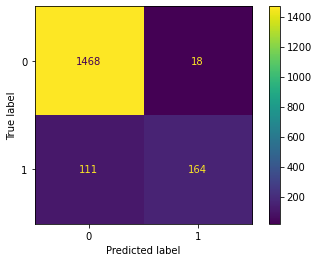

In [264]:
y_pred_catboost = chosen_model_cat.predict(X_test)

conf_matrix = confusion_matrix(y_test, y_pred_catboost)

# Визуализация матрицы ошибок
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot()
plt.grid(False)
plt.show()

Для построенной матрицы ошибок:

Точность (Precision) для класса 1 примерно равна 0.59, что указывает на долю истинно положительных результатов относительно всех положительных результатов, определённых моделью.

Полнота (Recall) для класса 1 примерно равна 0.9, что отражает способность модели обнаруживать истинные события класса 1. 

Итак, модель не совсем хорошо справляется с тем чтобы находить всех клиентов, которые уйдут. Однако можно смело заявлять, что делает она это умеет не рандомно. 

Построим график зависимости полноты (recall) и точности (precision), чтобы понять баланс между верно предсказанными положительными случаями и ложными срабатываниями.

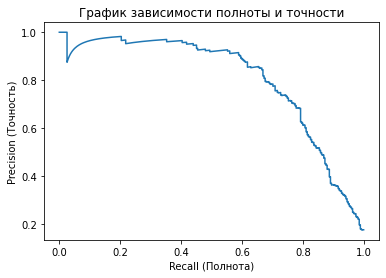

In [265]:
y_pred_proba_catboost = chosen_model_cat.predict_proba(X_test)[:, 1]

# Строим график precision-recall
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_catboost)
plt.plot(recall, precision)
plt.xlabel('Recall (Полнота)')
plt.ylabel('Precision (Точность)')
plt.title('График зависимости полноты и точности')
plt.show()

График зависимости полноты (recall) и точности (precision) показывает, что по мере увеличения полноты точность, как правило, уменьшается. Это типичный компромисс между полнотой и точностью: при увеличении способности модели правильно предсказывать положительные случаи (увеличение recall) возникает больше ложных срабатываний, что уменьшает точность. Максимальная точность достигается при низкой полноте, а высокая полнота соответствует низкой точности.

На этапе обучения моделей была подобрана модель CatBoostClassifier c параметрами 'models__learning_rate': 0.3, 'models__l2_leaf_reg': 3, 'models__iterations': 200, 'models__depth': 4. Метрика roc-auc у нас достигла 0,92 на тестовой выборке. После проверки модели на адекватеность при помощи DummyClassifier можно смело рекомендовать нашу модель, т.к. она имеет лучшую предсказательную способность, чем стандарное решение для предсказания.

Для построенной матрицы ошибок:

Точность (Precision) для класса 1 примерно равна 0.59, что указывает на долю истинно положительных результатов относительно всех положительных результатов, определённых моделью.

Полнота (Recall) для класса 1 примерно равна 0.9, что отражает способность модели обнаруживать истинные события класса 1.

График зависимости полноты (recall) и точности (precision) показывает, что по мере увеличения полноты точность, как правило, уменьшается. Это типичный компромисс между полнотой и точностью: при увеличении способности модели правильно предсказывать положительные случаи (увеличение recall) возникает больше ложных срабатываний, что уменьшает точность. Максимальная точность достигается при низкой полноте, а высокая полнота соответствует низкой точности.

Приступим к анализу важности факторов.

## Анализ важности факторов

In [392]:
cat_model = chosen_model_cat.named_steps['models']
preprocessor = chosen_model_cat.named_steps['preprocessor']
feature_importances = cat_model.get_feature_importance(prettified=True)

X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

def get_feature_names_from_pipeline(preprocessor, ohe_columns, num_columns):
    ohe = preprocessor.named_transformers_['ohe'].named_steps['ohe']
    
    if hasattr(ohe, 'get_feature_names'):
        ohe_feature_names = ohe.get_feature_names(ohe_columns)
    else:
        raise AttributeError("OneHotEncoder не имеет метода get_feature_names или get_feature_names_out")
    
    
    num_feature_names = num_columns

    remainder = preprocessor.transformers_[-1]
    remainder_features = []
    if remainder[0] == 'remainder' and remainder[1] == 'passthrough':
        remainder_columns = remainder[2]
        if isinstance(remainder_columns, slice):
            remainder_columns = X_train.columns[remainder_columns].tolist()
        remainder_features = remainder_columns

    return list(ohe_feature_names) + list(num_feature_names) + list(remainder_features)

feature_names = get_feature_names_from_pipeline(preprocessor, ohe_columns, num_columns)

In [395]:
explainer = shap.TreeExplainer(cat_model, feature_names=feature_names)
shap_values = explainer(X_test_transformed)

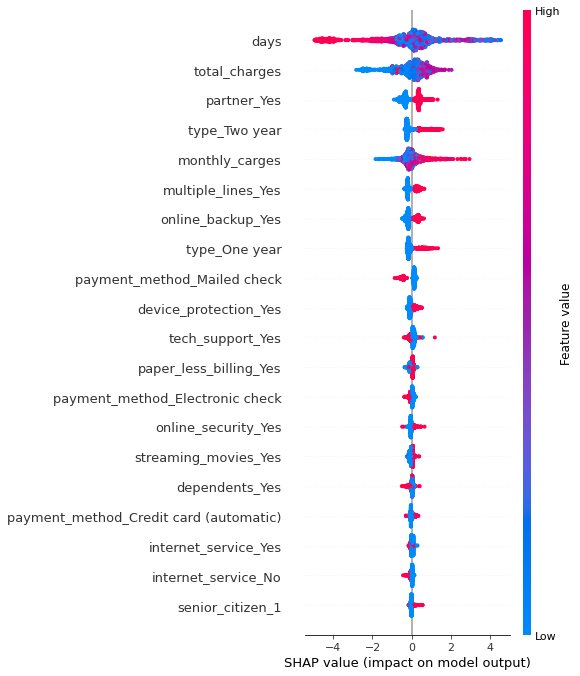

In [398]:
shap.summary_plot(shap_values, features=X_test_transformed, feature_names=feature_names)

Анализ значимости признаков с помощью SHAP показывает, что наибольшее влияние на вероятность того, что клиент откажется от услуг компании - количество дней подписки. Интерпретировать можно по разному. Например, в если интерпретировать в пользу модели - это то, что клиенты, которые давно пользуются услугами не станут уходить или отказываться от услуг, соотвественно, за них можно не переживать и стоит уделить внимание новым клиентам. Также это может говорить о проблемах в собранных данных. Ушедшие клиенты, наравне с текущими присутствуют в датасете, что может подсказывать модели, что эти клиенты являются ушедшими. Мы не будем считать это утечкой и далее рассмотрим график зависимости входного и целевого признаков.

Также можно смело говорить о том, что количество затрат также влияет на уход клиента. Если клиент тратит мало - он вне зоны риска, а вот клиенты, которые тратят больше - отказываются от услуг. Также на факт ухода влияют месячные расходы и наличие прартнера. 

Построим график зависимости входного и целевого признаков.

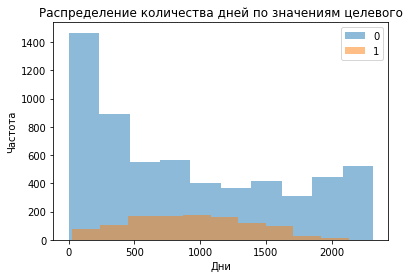

In [400]:
plt.hist(df[df['client_left'] == 0]['days'], alpha=0.5, label='0') # alpha для прозрачности
plt.hist(df[df['client_left'] == 1]['days'], alpha=0.5, label='1')
plt.xlabel('Дни')
plt.ylabel('Частота')
plt.title('Распределение количества дней по значениям целевого')
plt.legend()
plt.show()

Таким образом, гистограмма показывает распределение количества дней в зависимости от значения целевого признака client_left.

⦁ Значение 0 (клиент остался): Обозначено голубым цветом, заметно, что большая часть значений сгруппирована в начале. Частота снижается по мере увеличения количества дней.

⦁ Значение 1 (клиент ушел): Обозначено коричневым цветом. Количество таких клиентов меньше по сравнению с теми, кто остался (0). Распределение более равномерное, но также снижается по мере увеличения дней.

Это может свидетельствовать о том, что клиенты, которые остаются, обычно делают это сравнительно в первые периоды, а те, кто уходит, распределены более равномерно.

Итак, на этапе анализа важности факторов мы построили график SHAP. Анализ значимости признаков с помощью SHAP показывает, что наибольшее влияние на вероятность того, что клиент откажется от услуг компании - количество дней подписки. Интерпретировать можно по разному. Например, в если интерпретировать в пользу модели - это то, что клиенты, которые давно пользуются услугами не станут уходить или отказываться от услуг, соотвественно, за них можно не переживать и стоит уделить внимание новым клиентам. Также это может говорить о проблемах в собранных данных. Ушедшие клиенты, наравне с текущими присутствуют в датасете, что может подсказывать модели, что эти клиенты являются ушедшими. Мы не будем считать это утечкой и далее рассмотрим график зависимости входного и целевого признаков.

Также можно смело говорить о том, что количество затрат также влияет на уход клиента. Если клиент тратит мало - он вне зоны риска, а вот клиенты, которые тратят больше - отказываются от услуг. Также на факт ухода влияют месячные расходы и наличие прартнера. Также был построен график зависимости входного и целевого признаков.
гистограмма показала распределение количества дней в зависимости от значения целевого признака client_left.

⦁ Значение 0 (клиент остался): Обозначено голубым цветом, заметно, что большая часть значений сгруппирована в начале. Частота снижается по мере увеличения количества дней.

⦁ Значение 1 (клиент ушел): Обозначено коричневым цветом. Количество таких клиентов меньше по сравнению с теми, кто остался (0). Распределение более равномерное, но также снижается по мере увеличения дней.

Это может свидетельствовать о том, что клиенты, которые остаются, обычно делают это сравнительно в первые периоды, а те, кто уходит, распределены более равномерно.

# Вывод

Итак, на этапе подключение к базе и Загрузка таблиц sql мы подключились к БД и провели первичный осмотр таблиц.

На этапе первичного исследования таблиц были построены графики к каждому из признаков. Было выявлено, что принадлежность к полу распределена в данных равномерно. Пожилых чуть более тысячи. Партнеры есть почти у половины клиентов. Дети чаще всего отсутствуют. Подключены клиенты чаще всего по оптоволокну. Дополнительные услуги у клиентов по услугам интернета чаще не подключены. По телефонии клиенты чаще пользуются однопоточной линией.

На этапе объединения таблиц и предобработки данных был написан запрос к БД и данные были слиты в один датасет. Далее мы обработали типы колонок и привели их правильному типу. Следом мы вывели целевой признак по факту отказа от услуг - если дата есть - значит клиент отказался. Также мы вывели признак о длительности пользования услугами и удалили колонки с информацией о датах. И, наконец, заполнили пропуски: в случае с типом подключения будем исходить из информации о налаичии телефонной связи у клиента. Если она есть - проставим DSL, если нет - оптоволокно, а информацию об всех услугах заполнили значением "No internet" или "No phone".

На этапе изучения графиков корреляции: 

Анализ матриц корреляции выявил различия в связи признаков с целевой переменной (client_left) в зависимости от её значения (1 или 0):

*   `monthly_charges`: Более сильная корреляция с `internet_service` при `target = 1` (0.88) по сравнению с `target = 0` (0.86) указывает на то, что от типа подключения будет зависеть и стоимость.

*   `monthly_charges`: Одинаково высокая корреляция с `streaming_movies` и `streaming_tv` при `target = 0` (0.86) относительно `target = 0` (0.86). Что может говорить о том, что чем больше клиент платит за услуги, тем реже он планирует уйти.

*   `multiple_lines`: Одинаково высоко коррелирует с `internet_service` при `target = 1` (0.88) и при `target = 0` (0.88), что может указывать на то, что от типа подключения интернета зависит, есть ли услуги телефона у человека, что логично. Удалять этот признак мы не будем.
* `days` одинаково сильно коррелирует с `total_charges` и при `target = 1` (0.84), и при `target = 0` (0.84), что подчеркивает что, чем больше люди пользуются услугами, тем больше денег они оставили компании.

На этапе подготовки данных к обучению данные были подготовлены, разделены на выборки, создан пайплайн и выбраны модели для перебора гиперпараметров.

На этапе обучения моделей была подобрана модель CatBoostClassifier c параметрами 'models__learning_rate': 0.3, 'models__l2_leaf_reg': 3, 'models__iterations': 200, 'models__depth': 4. Метрика roc-auc у нас достигла 0,92 на тестовой выборке. После проверки модели на адекватеность при помощи DummyClassifier можно смело рекомендовать нашу модель, т.к. она имеет лучшую предсказательную способность, чем стандарное решение для предсказания.

Для построенной матрицы ошибок:

Точность (Precision) для класса 1 примерно равна 0.59, что указывает на долю истинно положительных результатов относительно всех положительных результатов, определённых моделью.

Полнота (Recall) для класса 1 примерно равна 0.9, что отражает способность модели обнаруживать истинные события класса 1.

График зависимости полноты (recall) и точности (precision) показывает, что по мере увеличения полноты точность, как правило, уменьшается. Это типичный компромисс между полнотой и точностью: при увеличении способности модели правильно предсказывать положительные случаи (увеличение recall) возникает больше ложных срабатываний, что уменьшает точность. Максимальная точность достигается при низкой полноте, а высокая полнота соответствует низкой точности.

На этапе анализа важности факторов мы построили график SHAP. Анализ значимости признаков с помощью SHAP показывает, что наибольшее влияние на вероятность того, что клиент откажется от услуг компании - количество дней подписки. Интерпретировать можно по разному. Например, в если интерпретировать в пользу модели - это то, что клиенты, которые давно пользуются услугами не станут уходить или отказываться от услуг, соотвественно, за них можно не переживать и стоит уделить внимание новым клиентам. Также это может говорить о проблемах в собранных данных. Ушедшие клиенты, наравне с текущими присутствуют в датасете, что может подсказывать модели, что эти клиенты являются ушедшими. Мы не будем считать это утечкой и далее рассмотрим график зависимости входного и целевого признаков.

Также можно смело говорить о том, что количество затрат также влияет на уход клиента. Если клиент тратит мало - он вне зоны риска, а вот клиенты, которые тратят больше - отказываются от услуг. Также на факт ухода влияют месячные расходы и наличие прартнера. Также был построен график зависимости входного и целевого признаков. гистограмма показала распределение количества дней в зависимости от значения целевого признака client_left.

⦁ Значение 0 (клиент остался): Обозначено голубым цветом, заметно, что большая часть значений сгруппирована в начале. Частота снижается по мере увеличения количества дней.

⦁ Значение 1 (клиент ушел): Обозначено коричневым цветом. Количество таких клиентов меньше по сравнению с теми, кто остался (0). Распределение более равномерное, но также снижается по мере увеличения дней.

Это может свидетельствовать о том, что клиенты, которые остаются, обычно делают это сравнительно в первые периоды, а те, кто уходит, распределены более равномерно.

Таким образом можно смело рекомендовать заказчику более щепетильно подходить к предоставлению услуг новым клиентам, предоставляя, например, персональные скидки или промо-акции. Предлагать более выгодные условия и увеличивать скорость интернета. 